# Hyperparameters tuning (MultiOutput estimators for all eigenfrequencies)

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import pickle

In [2]:
# Load dataframes from binary files
fam = '03'
base_dir = r'D:\Entwicklungen\share\DataScienceProject'

all_data = {}
fam_dir = os.path.join(base_dir, fam, 'data-' + fam)
all_data[fam] = {}

ft_param_path = os.path.join(base_dir, 'sep24_cds_int_us-welding', 'ft_files', str(fam) + '_feat_parameters.ft')
df_params = pd.read_feather(ft_param_path)

The columns of the DataFrame df_params are listed in the text file df_params_cols.txt

In [3]:
lst_param = df_params.columns.to_list()

# Load variables

The explanatory variables are redefined

In [5]:
lst_expl = lst_param[1:4] + lst_param[5:7] + lst_param[8:24] + lst_param[32:34]

X = df_params[lst_expl]
X.head()

,dim_x,dim_y,dim_z,slot_x_length,slot_x_distance,slot_z_length,slot_z_distance,chamfer_x_dim_y,chamfer_x_dim_z,chamfer_y_dim_x,...,elefoot_x,elefoot_z,cut_x_start,cut_x_end,cut_x_depth,cut_z_start,cut_z_end,cut_z_depth,seg_x_out,seg_z_out
0,175.06,121.95,240.31,75.993,43.235,78.219,59.508,15.6380,12.0740,1.8138,...,4.26140,4.12380,28.510,97.910,0.88177,25.293,66.060,1.99450,55.3025,57.7760
1,173.45,122.77,238.13,81.168,45.859,78.924,57.208,11.7180,9.9347,9.6338,...,1.36970,3.88410,40.496,79.356,4.85900,26.997,56.481,4.80300,50.2765,58.1210
2,175.85,116.71,238.10,77.532,45.260,80.099,49.215,2.4722,9.9912,3.8140,...,3.43750,1.33560,21.081,83.599,1.21780,22.264,51.204,0.81847,51.1600,63.3175
3,173.51,116.37,238.30,82.428,51.007,74.757,50.840,12.1080,12.8380,1.8759,...,0.86571,4.01320,53.546,63.529,4.16500,37.379,58.304,1.02820,42.6395,61.3350
4,175.60,118.72,241.04,76.576,45.981,78.773,64.702,15.8700,11.0240,9.8682,...,2.86530,0.97684,36.388,89.119,0.64304,27.381,51.502,0.74029,51.5485,55.4490


# Definition of the target(s)

The goal is to predict a set of eigenfrequencies. Since the target is multidimensional the variables will be stored in the matrix Y. The frequencies around the longitudinal mode are the most interesting in our case. By choosing the frequencies of the modes from 50 to 85, we ensure that the longitudinal mode will always be in the range of selected frequencies.

In [7]:
# Target variables: selection of all frequencies of modes 65 to 85
lst_freq = lst_param[101:122]

Y = df_params[lst_freq]
Y.head()

,freq_65,freq_66,freq_67,freq_68,freq_69,freq_70,freq_71,freq_72,freq_73,freq_74,...,freq_76,freq_77,freq_78,freq_79,freq_80,freq_81,freq_82,freq_83,freq_84,freq_85
0,16917.342,17096.891,17135.160,17146.528,17625.674,18330.368,18506.897,18672.122,18788.989,18846.436,...,19095.403,19217.965,19279.254,19311.640,20316.043,20572.699,20852.411,21007.577,22042.081,22246.846
1,16530.134,16576.299,16741.655,16743.897,17522.855,17855.674,17877.667,18136.533,18156.928,18298.729,...,18435.617,18516.417,18876.657,19386.656,19896.947,19969.016,20487.623,20537.333,21448.323,21657.039
2,17233.678,17322.752,17438.316,17588.147,18187.977,18257.994,18267.811,18284.016,18347.184,18526.704,...,18788.769,19237.203,19256.489,20087.459,20214.271,20731.439,21076.573,21351.086,21746.397,21981.714
3,17165.809,17240.235,17308.679,17392.083,17608.856,17775.082,18059.941,18377.043,18380.486,18442.354,...,19014.610,19168.498,19288.770,19627.057,20209.177,20551.074,20894.240,21101.402,21288.858,21649.534
4,16798.846,16960.792,17424.349,17629.080,18067.931,18315.783,18381.090,18497.798,18635.488,18906.200,...,19012.524,19354.988,19644.580,19813.899,20459.265,20980.660,21029.941,21649.551,21887.022,22085.694


In [8]:
# New Train-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=55)

## Multi-Output Regressor

We build a pipeline to include the scaling of the input variables and the Multi-Output wrapping the regressor. The optimization of the hyperparameters will be performed on this pipeline. The start estimator LightGBM is set up with some already customized hyperparameters.
In the case of an multi-output prediction, the coefficient of determination R² calculated by weighting all the targets equally if the parameter multioutput = 'uniform_average' is specified.


In [10]:
preprocessor = ColumnTransformer(transformers=[
                                    ('numerical', StandardScaler(), lst_expl)
                                    ])

start_lgbm = LGBMRegressor(n_estimators=400,
                      num_leaves=4,
                      min_child_samples=5,
                      learning_rate=0.1,
                      force_col_wise=True)

pipe_start_lgbm = Pipeline([
                        ('scaler', preprocessor),
                        ('multiregressor', MultiOutputRegressor(start_lgbm))
                        ])
    

In [11]:
# Start model
pipe_start_lgbm.fit(X_train, Y_train)
Y_pred_start_lgbm = pipe_start_lgbm.predict(X_test)

[LightGBM] [Info] Total Bins 5851
[LightGBM] [Info] Number of data points in the train set: 6392, number of used features: 23
[LightGBM] [Info] Start training from score 19854.619703
[LightGBM] [Info] Total Bins 5851
[LightGBM] [Info] Number of data points in the train set: 6392, number of used features: 23
[LightGBM] [Info] Start training from score 20077.400624
[LightGBM] [Info] Total Bins 5851
[LightGBM] [Info] Number of data points in the train set: 6392, number of used features: 23
[LightGBM] [Info] Start training from score 20295.297913
[LightGBM] [Info] Total Bins 5851
[LightGBM] [Info] Number of data points in the train set: 6392, number of used features: 23
[LightGBM] [Info] Start training from score 20619.230115
[LightGBM] [Info] Total Bins 5851
[LightGBM] [Info] Number of data points in the train set: 6392, number of used features: 23
[LightGBM] [Info] Start training from score 20889.818784
[LightGBM] [Info] Total Bins 5851
[LightGBM] [Info] Number of data points in the trai

In [12]:
# Check the score of the start model
print ('Score of the test set:', pipe_start_lgbm.score(X_test, Y_test))

Score of the test set: 0.9946680474301611


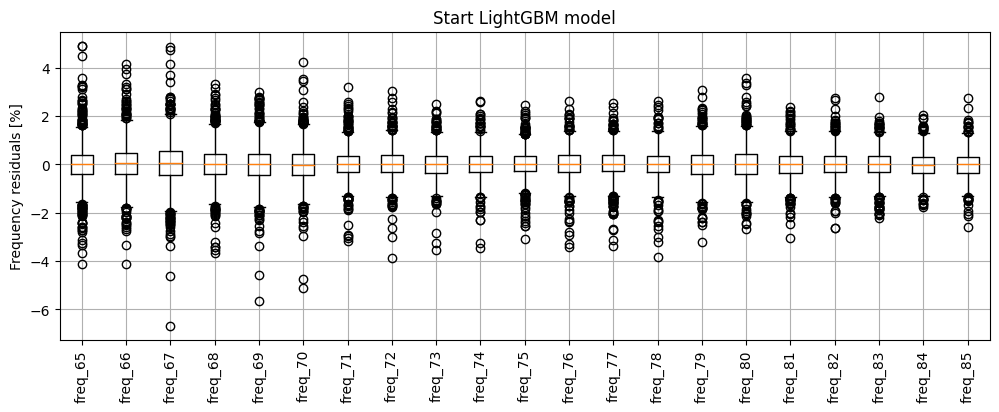

In [19]:
# The residuals are calculated in relation ot the true values
df_freq_residuals = (Y_pred_start_lgbm-Y_test)/Y_test*100

fix, ax = plt.subplots(figsize=(12, 4))
plt.boxplot(df_freq_residuals, labels=lst_freq)
plt.xticks(rotation=90)
plt.grid(True)
plt.title('Start LightGBM model')
plt.ylabel('Frequency residuals [%]')
plt.show()

# Hyperparameters tuning
When the MultiOutputRegressor is wrapping a regressor. the prefix "estimator__" has to be specified to access the underlying LGMB Regressor. BayesSearchCV will apply the same hyperparameters to all regressors in the wrapper.

In [14]:
params_lgbm = {'multiregressor__estimator__n_estimators': Integer(400, 8000),
                'multiregressor__estimator__num_leaves': Integer(4, 12),
                'multiregressor__estimator__min_child_samples': Integer(4, 8),
                'multiregressor__estimator__learning_rate': Real(1e-3, 1e0, prior='log-uniform'),
                'multiregressor__estimator__reg_alpha': Real(1e-5, 1e-2, prior='log-uniform'),
                'multiregressor__estimator__reg_lambda': Real(1e-5, 1e-2, prior='log-uniform')}

bayes_search_lgbm = BayesSearchCV(estimator=pipe_start_lgbm,
                                search_spaces=params_lgbm,
                                n_iter=32,
                                scoring='r2',
                                random_state=55,
                                cv=KFold(n_splits=5, shuffle=True, random_state=55),
                                verbose=True,
                                n_jobs=-1)

In [15]:
# Perform the Bayesian search
bayes_search_lgbm.fit(X_train, Y_train)
print ('Best score:', bayes_search_lgbm.best_score_)
print ('Best parameters:', bayes_search_lgbm.best_params_)
print ('Score of the test set:', bayes_search_lgbm.score(X_test, Y_test))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

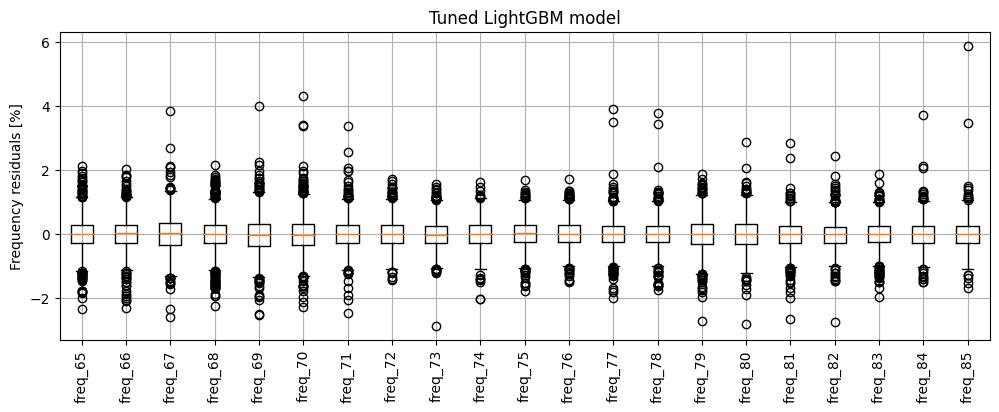

In [20]:
# Prediction
Y_pred_tuned_lgbm = bayes_search_lgbm.predict(X_test)
Y_pred_tuned_lgbm = pd.DataFrame(Y_pred_tuned_lgbm, index=X_test.index, columns=lst_freq)

# Calculation of the residuals
df_freq_residuals_tuned = (Y_pred_tuned_lgbm-Y_test)/Y_test*100

fix, ax = plt.subplots(figsize=(12, 4))
plt.boxplot(df_freq_residuals_tuned, labels=lst_freq)
plt.xticks(rotation=90)
plt.grid(True)
plt.title('Tuned LightGBM model')
plt.ylabel('Frequency residuals [%]')
plt.show()

The mean absolute percentage error (MAPE) quantifies the average absolute difference between predicted and observed values as percentage of the observed (true) values. This metric can be appropriate in our specific case, where the target variables span a broad range of frequencies (between 13 and 27 kHz). The argument "raw_values" allows to determine the error for each frequency.

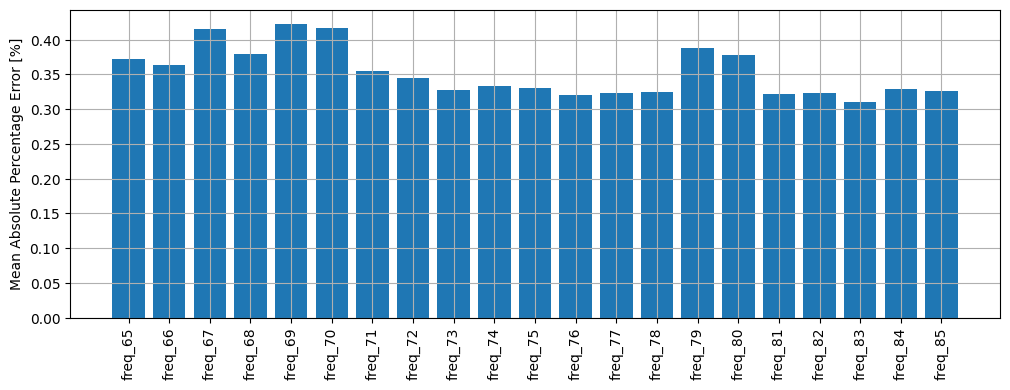

In [21]:
# Calculation of the Mean Absolute Percentage Error
mape = mean_absolute_percentage_error(Y_test, Y_pred_tuned_lgbm, multioutput='raw_values')

n_freq = len(lst_freq)
fig = plt.figure(figsize=(12, 4))
plt.bar(x=range(n_freq), height=mape*100)
plt.ylabel('Mean Absolute Percentage Error [%]')
plt.xticks(range(n_freq), lst_freq, rotation=90)
plt.grid()
plt.show()

# Conclusion

 The mean absolute error is increasing with the slot class and therefore with the complexity of the geometry. A mean error of 100 Hz could be at the limit of a good prediction in case of a very close neighbor mode.

Dump fitted models as pickle files

In [18]:
dump_dir = os.path.join(base_dir, 'sep24_cds_int_us-welding', 'model_dumps')

pickle.dump(bayes_search_lgbm.best_estimator_, open(os.path.join(dump_dir, '03-ext_4_model_lgbm_tuned_all_frequencies.pkl'), 'wb'))